## Лабораторная работа №3 "Апроксимация нелинейных функций"

**Цель работы:** изучить построение полносвязных нейронных сетей для аппроксимации нелинейной функции и сравнить обычную последовательную архитектуру с ветвящейся сетью.

## Теоретические сведения

Полносвязная нейронная сеть (многослойный персептрон) решает задачу аппроксимации как задачу обучения отображения
$(t \mapsto f(t))$ по набору примеров «аргумент–значение функции».
Сеть получает на вход значения аргумента, на выходе должна воспроизводить значения функции, а параметры подбираются
так, чтобы средняя ошибка между предсказанием и эталоном была минимальной.

В качестве функции \(f(t)\) можно использовать любую одномерную нелинейную зависимость. В данной работе в качестве
теста берётся функция `sin(2πt)`, но полученные модели так же применимы для аппроксимации других сигналов.

Важную роль играют нелинейные функции активации. Если между линейными слоями не использовать нелинейность, то вся сеть
сведётся к одному линейному преобразованию и не сможет описывать сложную зависимость. В работе используется `Tanh`,
подходящая для гладких нелинейных функций.

В Keras данные обычно подаются в виде массивов NumPy, архитектура сети задаётся через Sequential или Functional API,
а обновление параметров выполняет оптимизатор (например, `Adam`). В качестве функции потерь при аппроксимации удобно
использовать среднеквадратичную ошибку `mse`.

## Лабораторная работа №2. Часть 1

In [1]:
# Установка дополнительных пакетов
!pip install tensorflow pydot

In [2]:
# Базовые библиотеки
import math
import numpy as np
import matplotlib.pyplot as plt

# Keras / TensorFlow
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils

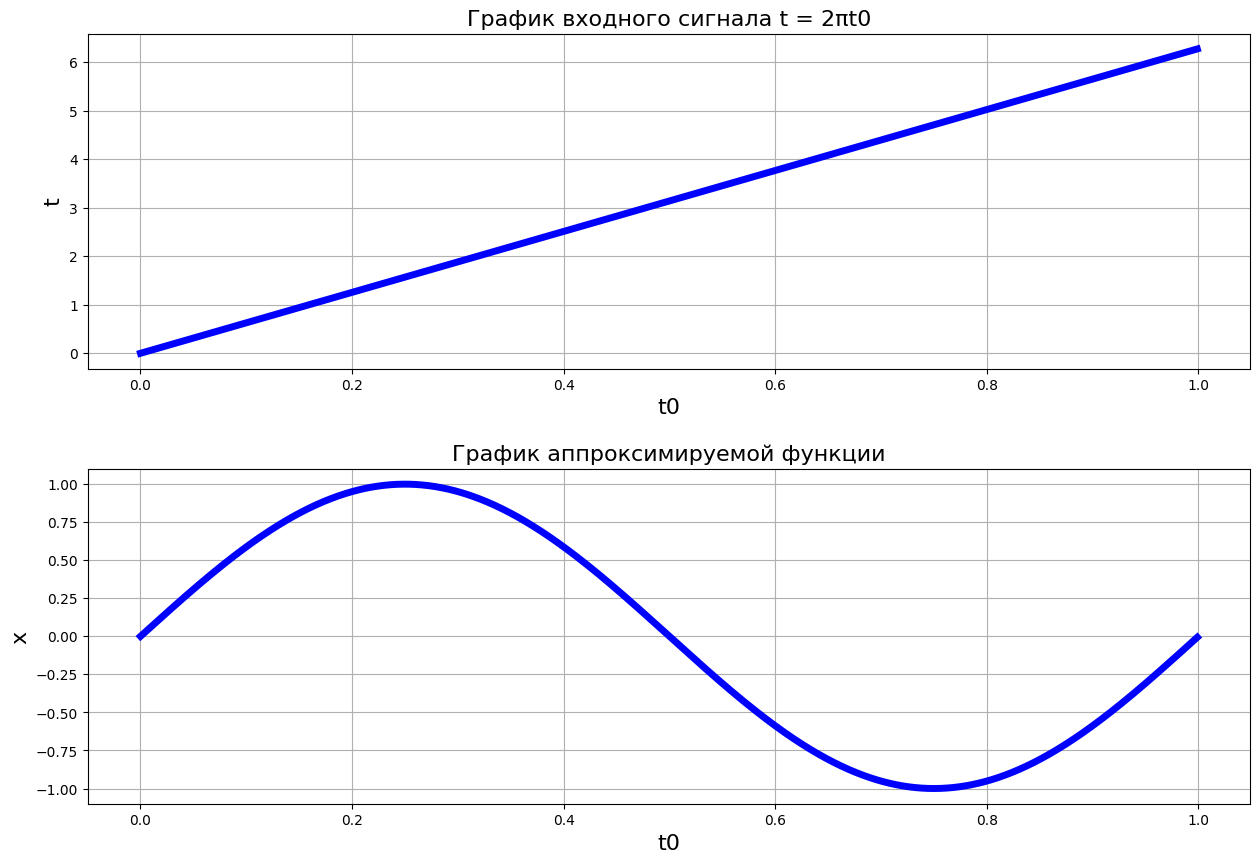

In [3]:
# Создание обучающей выборки
t0 = np.arange(0, 1, 0.001, dtype=np.float32)
t  = 2 * math.pi * t0
x  = np.sin(t).astype(np.float32)

# Прорисовка графиков обучающей выборки
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(t0, t, "b", linewidth=5)
plt.title("График входного сигнала t = 2πt0", fontsize=16)
plt.ylabel("t", fontsize=16)
plt.xlabel("t0", fontsize=16)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t0, x, "b", linewidth=5)
plt.title("График аппроксимируемой функции", fontsize=16)
plt.ylabel("x", fontsize=16)
plt.xlabel("t0", fontsize=16)
plt.grid()

plt.subplots_adjust(wspace=0, hspace=0.3)  # задаёт зазор между графиками
plt.show()

In [4]:
# Модель полносвязной сети для аппроксимации функции
def NN_sin_sequential(in_parameters: int):
    model = Sequential([
        Dense(50, activation="relu", input_shape=(in_parameters,)),
        Dense(50, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss="mse")
    return model

In [5]:
def NN_sin_functional(in_shape):
    model_input = Input(shape=in_shape)
    x = Dense(50, activation="relu")(model_input)
    x = Dense(50, activation="relu")(x)
    model_out = Dense(1)(x)

    model = Model(model_input, model_out, name="NNSin_Functional")
    model.compile(optimizer=Adam(learning_rate=0.01), loss="mse")
    return model

In [6]:
# Создание моделей (обычный Sequential и Functional API)
model_sin_seq = NN_sin_sequential(1)
model_sin = NN_sin_functional((1,))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== Структура модели (Sequential) ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701 (10.55 KB)

 Trainable params: 2,701 (10.55 KB)

...

Model: "NNSin_Functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701 (10.55 KB)

 Trainable params: 2,701 (10.55 KB)

 Non-trainable params: 0 (0.00 B)

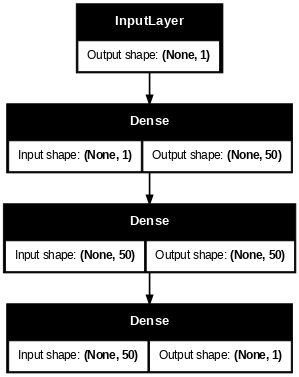

In [7]:
# Вывод структуры НС
print("=== Структура модели (Sequential) ===")
model_sin_seq.summary()

print("\n=== Структура модели (Functional API) ===")
model_sin.summary()
utils.plot_model(model_sin, dpi=60, show_shapes=True)

In [8]:
# Подготовка данных для Keras
# t0  – значения аргумента (от 0 до 1 с шагом 0.001)
# x   – значения аппроксимируемой функции sin(2πt)
X_train = t0.reshape(-1, 1)
y_train = x.reshape(-1, 1)

# Параметры обучения
n_epochs   = 100         # число проходов по всему набору данных
batch_size = 30          # размер мини‑батча

history_obj = model_sin.fit(
    X_train, y_train,
    epochs=n_epochs,
    batch_size=batch_size,
    verbose=0
)
history = history_obj.history['loss']

for epoch in range(19, n_epochs, 20):       # периодический вывод прогресса
    print(f"Epoch {epoch+1:3d}/{n_epochs}, loss = {history[epoch]:.6f}")

Epoch  20/100, loss = 0.000101
Epoch  40/100, loss = 0.001133
Epoch  60/100, loss = 0.000127
Epoch  80/100, loss = 0.000200
Epoch 100/100, loss = 0.000115


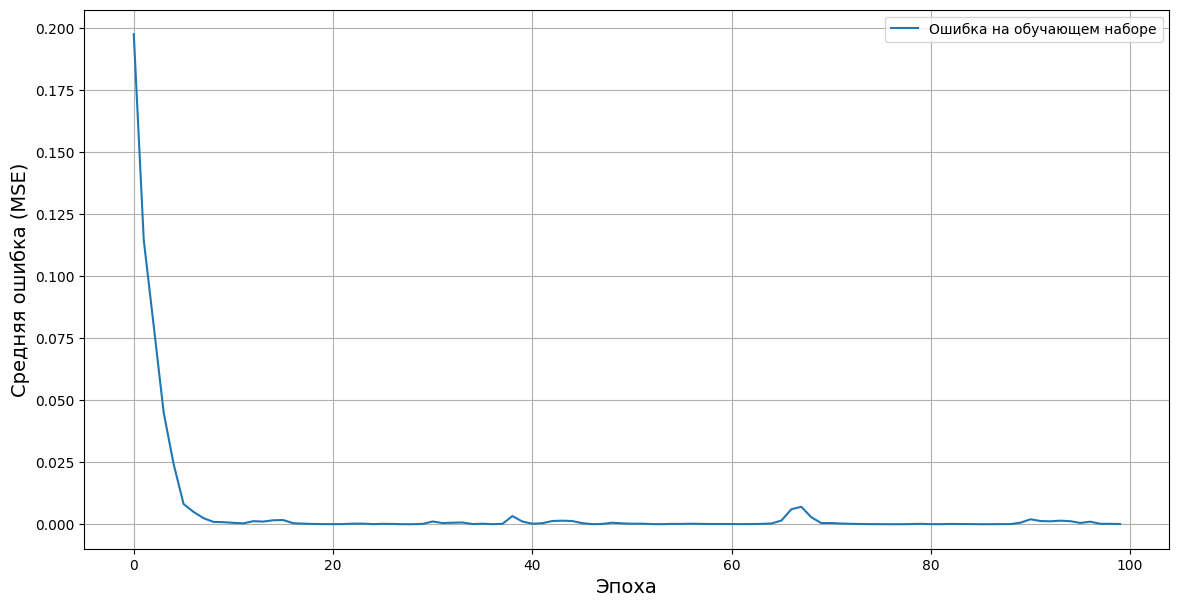

In [9]:
# Вывод графика процесса обучения
plt.figure(figsize=(14, 7))
plt.plot(history, label='Ошибка на обучающем наборе')
plt.ylabel('Средняя ошибка (MSE)', fontsize=14)
plt.xlabel('Эпоха', fontsize=14)
plt.grid()
plt.legend()
plt.show()

In [10]:
# Функция для расчёта MSE
def compute_mse(y_true, y_pred):
    """
    y_true, y_pred: массивы NumPy одинаковой формы
    """
    y_true = y_true.reshape(-1, 1)
    y_pred = y_pred.reshape(-1, 1)
    return float(np.mean((y_true - y_pred) ** 2))

In [11]:
# Моделирование работы НС (получение предсказаний)
pred_test = model_sin.predict(X_train, verbose=0).ravel()

# Расчёт MSE на обучающей выборке
train_mse = compute_mse(y_train, pred_test)
print(f"MSE (train) = {train_mse:.6f}")

MSE (train) = 0.000351


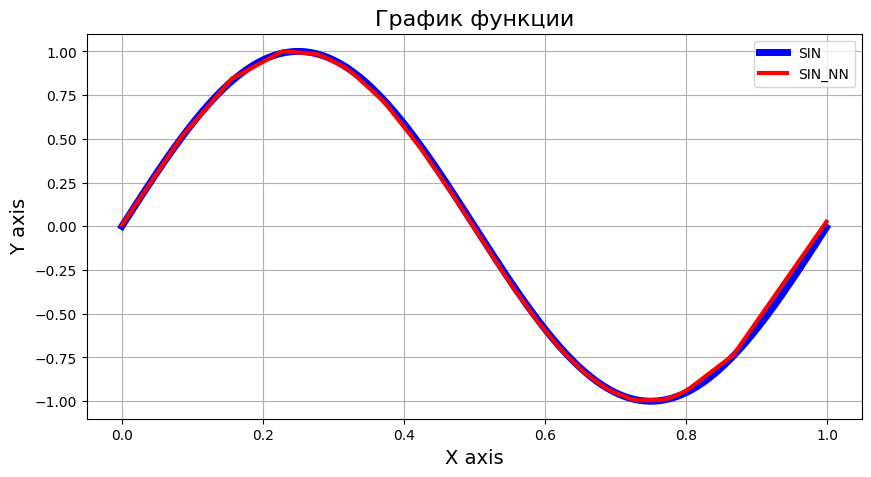

In [12]:
# Вывод графиков с результатом моделирования
plt.figure(figsize=(10, 5))
plt.plot(t0, x, 'b', linewidth=5, label='SIN')
plt.plot(t0, pred_test, 'r', linewidth=3, label='SIN_NN')
plt.title("График функции", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend(loc="upper right")
plt.show()

In [13]:
# Тестирование на данных, не входящих в обучающую выборку
t0_test = np.arange(0, 2, 0.001, dtype=np.float32)
t_test  = 2 * math.pi * t0_test
x_test  = np.sin(t_test).astype(np.float32)

X_test = t0_test.reshape(-1, 1)
y_test = x_test.reshape(-1, 1)

# Моделирование работы НС (получение предсказаний)
y_test_pred = model_sin.predict(X_test, verbose=0).ravel()

# Расчёт MSE на тестовой выборке
test_mse = compute_mse(y_test, y_test_pred)
print(f"MSE (test, NNSin) = {test_mse:.6f}")

MSE (test, NNSin) = 7.576560


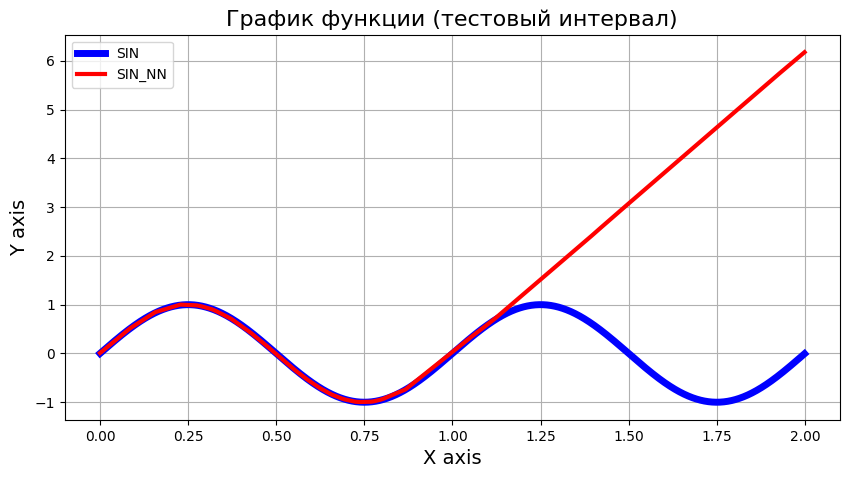

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(t0_test, x_test, 'b', label='SIN', linewidth=5)
plt.plot(t0_test, y_test_pred, 'r', label='SIN_NN', linewidth=3)
plt.title("График функции (тестовый интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend()
plt.show()

## Лабораторная работа №2. Часть 2

## Теоретические сведения
### Ветвящиеся архитектуры

Для решения более сложных задач простой последовательной цепочки слоёв может быть недостаточно. Иногда сети необходимо выделить общую скрытую репрезентацию входа, а затем обработать её параллельно, чтобы извлечь независимые группы признаков.

Ветвящаяся архитектура строится следующим образом:
1. **Общая часть (Shared part):** Входные данные проходят через один или несколько общих слоёв.
2. **Ветви (Branches):** Выход общей части подаётся одновременно на входы нескольких независимых слоёв (веток). Каждая ветвь обучается выделять «свои» специфические закономерности.
3. **Объединение (Merge):** Результаты вычислений из всех ветвей объединяются (чаще всего с помощью конкатенации тензоров по признаковому измерению).
4. **Выходной слой:** Объединённый тензор подаётся на финальный слой для получения итогового предсказания.

В Keras такая логика реализуется в Functional API: вы один раз пропускаете вход через общие слои, сохраняете результат в промежуточную переменную, затем подаёте её в каждую ветвь. Результаты ветвей объединяются функцией `concatenate`.

Одним из классических примеров ветвящейся архитектуры является Unet для задач сегментации изображений. В ней:

- **энкодер** (нисходящая часть) поэтапно уменьшает размер карты признаков, увеличивая число каналов и извлекая всё более абстрактные признаки;
- **декодер** (восходящая часть) восстанавливает пространственное разрешение с помощью операций upsampling / transposed‑conv;
- между соответствующими уровнями энкодера и декодера используются **skip‑соединения**: карты признаков из энкодера конкатенируются с картами декодера. Таким образом реализуются ветви, которые передают в декодер как высокоуровневые признаки, так и детальную пространственную информацию.

С точки зрения общей схемы, Unet как раз иллюстрирует идею *общей части + нескольких ветвей + объединения (concatenate)*, только в более сложном, многоуровневом варианте.

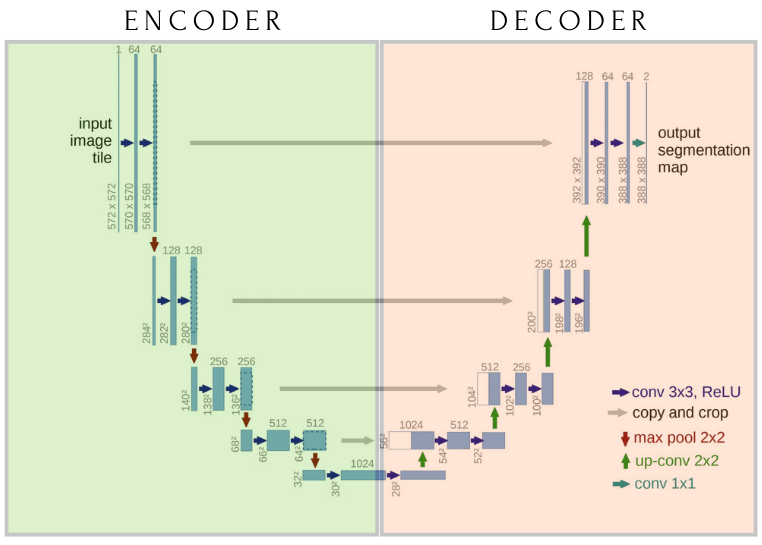

In [15]:
# Ветвящаяся модель для аппроксимации функции
def NN_sin_branch(in_shape):
    model_input = Input(shape=in_shape)

    # основная ветка
    x_main = Dense(50, activation="relu")(model_input)
    x_main = Dense(50, activation="relu")(x_main)

    # параллельная ветка
    x_branch = Dense(50, activation="sigmoid")(model_input)

    # объединение ветвей
    x_concat = concatenate([x_main, x_branch])

    # выходной слой
    model_out = Dense(1)(x_concat)

    model = Model(model_input, model_out, name="BranchSin_Functional")
    model.compile(optimizer=Adam(learning_rate=0.01), loss="mse")
    return model


=== Структура ветвящейся модели (Keras) ===


Model: "BranchSin_Functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 50)        │        100 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 50)        │      2,550 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 50)        │        100 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ dense_7[0][0],    │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │        101 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,851 (11.14 KB)

 Trainable params: 2,851 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

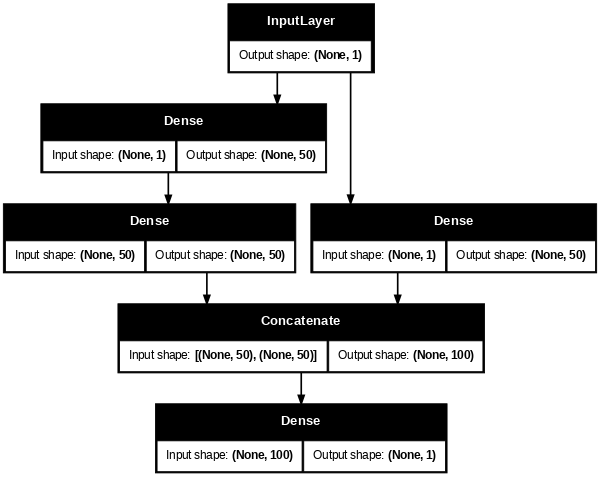

In [16]:
# Создание модели
model_branch = NN_sin_branch((1,))

print("\n=== Структура ветвящейся модели (Keras) ===")
model_branch.summary()
utils.plot_model(model_branch, dpi=60, show_shapes=True)

In [17]:
# Подготовка данных для Keras
X_train = t0.reshape(-1, 1)
y_train = x.reshape(-1, 1)

# Параметры обучения
n_epochs   = 100
batch_size = 30

history_branch_obj = model_branch.fit(
    X_train, y_train,
    epochs=n_epochs,
    batch_size=batch_size,
    verbose=0
)
history_branch = history_branch_obj.history['loss']

for epoch in range(19, n_epochs, 20):
    print(f"[Branch] Epoch {epoch+1:3d}/{n_epochs}, loss = {history_branch[epoch]:.6f}")

[Branch] Epoch  20/100, loss = 0.000309
[Branch] Epoch  40/100, loss = 0.000941
[Branch] Epoch  60/100, loss = 0.000592
[Branch] Epoch  80/100, loss = 0.000625
[Branch] Epoch 100/100, loss = 0.000481


MSE (train, BranchSin) = 0.000241


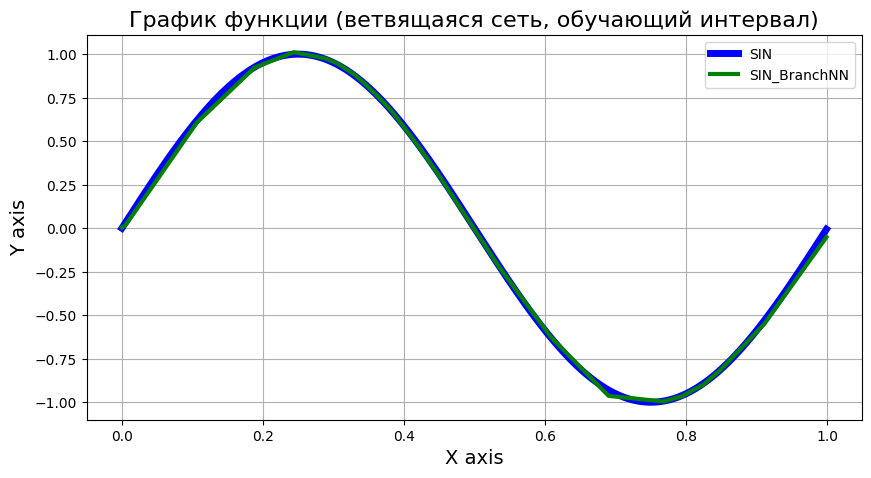

In [18]:
# Моделирование работы ветвящейся НС (обучающий интервал)
pred_branch_train = model_branch.predict(X_train, verbose=0).ravel()

# Расчёт MSE на обучающей выборке для ветвящейся сети
branch_train_mse = compute_mse(y_train, pred_branch_train)
print(f"MSE (train, BranchSin) = {branch_train_mse:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(t0, x, 'b', linewidth=5, label='SIN')
plt.plot(t0, pred_branch_train, 'g', linewidth=3, label='SIN_BranchNN')
plt.title("График функции (ветвящаяся сеть, обучающий интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend(loc="upper right")

MSE (test, BranchSin) = 4.890474


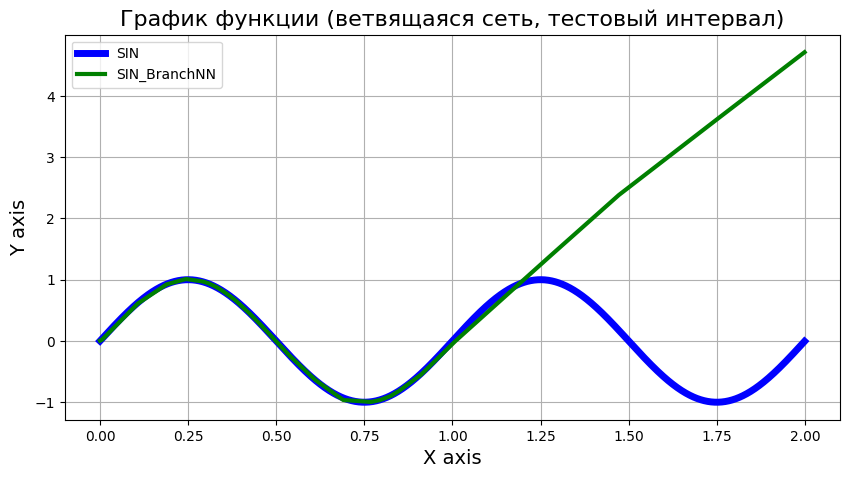

In [19]:
# Тестирование на данных, не входящих в обучающую выборку
t0_test = np.arange(0, 2, 0.001, dtype=np.float32)
t_test  = 2 * math.pi * t0_test
x_test  = np.sin(t_test).astype(np.float32)

X_test = t0_test.reshape(-1, 1)
y_test = x_test.reshape(-1, 1)

y_branch_test = model_branch.predict(X_test, verbose=0).ravel()

# Расчёт MSE на тестовом интервале для ветвящейся сети
branch_test_mse = compute_mse(y_test, y_branch_test)
print(f"MSE (test, BranchSin) = {branch_test_mse:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(t0_test, x_test, 'b', label='SIN', linewidth=5)
plt.plot(t0_test, y_branch_test, 'g', label='SIN_BranchNN', linewidth=3)
plt.title("График функции (ветвящаяся сеть, тестовый интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend()
plt.show()

## Порядок выполнения работы

1. Студент выбирает номер варианта согласно списку группы.  
2. По номеру варианта выбирается целевая **нелинейная** функция \(Y=f(X)\) из таблицы вариантов.  
3. Сгенерировать обучающую выборку \((X, Y)\) на интервале, указанном преподавателем (например, \(X \in [0, 2\pi]\)), добавить тестовый интервал, не пересекающийся с обучающим.  
4. Реализовать в Keras две модели:
   - последовательную полносвязную сеть (NNSin);
   - ветвящуюся сеть (BranchSin) с двумя параллельными ветвями и последующей конкатенацией признаков.
5. Обучить обе сети на одной и той же выборке, подобрать гиперпараметры (число эпох, размер батча, скорость обучения) так, чтобы добиться разумной аппроксимации функции.
6. Сравнить качество:
   - по графикам на обучающем и тестовом интервале;
   - по числовым метрикам (MSE на обучающей и тестовой выборках);
   - по сложности модели (число параметров), форме графа сети (`model.summary()` / `utils.plot_model`).
7. Заполнить таблицу экспериментов, сделать краткие выводы о влиянии архитектуры (последовательная vs ветвящаяся) и гиперпараметров на качество аппроксимации.

### Таблица вариантов

| № варианта | Функция              | № варианта | Функция                    |
|-----------:|----------------------|-----------:|----------------------------|
| 1          | Y = 5sin(X+3)        | 26         | Y = 2sin(X) - 5            |
| 2          | Y = sin(X)           | 27         | Y = sin(X) + 6             |
| 3          | Y = cos(X)/sin(X)    | 28         | Y = cos(X)*3sin(X)         |
| 4          | Y = 4X^2 + 1         | 29         | Y = sin(X) + 10            |
| 5          | Y = cos(X)           | 30         | Y = 2cos(X)sin(X)          |
| 6          | Y = cos(X)/2         | 31         | Y = 15X^2 - 4              |
| 7          | Y = tan(X)           | 32         | Y = 3tan(X)                |
| 8          | Y = cot(X)           | 33         | Y = 2 + sin(X)             |
| 9          | Y = 2sin(X)          | 34         | Y = 2sin(X-6) - 5          |
| 10         | Y = X^2 + 5          | 35         | Y = X^2 - 6                |
| 11         | Y = cos(X)/sin(X)    | 36         | Y = cos(X)/(3sin(X))       |
| 12         | Y = sin(X) + 5       | 37         | Y = sin(X) - 2             |
| 13         | Y = cos(X)sin(X)     | 38         | Y = 2cos(X)                |
| 14         | Y = 15X^2            | 39         | Y = 5X^2 - 4               |
| 15         | Y = 2tan(X)          | 40         | Y = tan(X)/3               |
| 16         | Y = 1 + sin(X)       | 41         | Y = 2 + 3sin(X)            |
| 17         | Y = 4X^2 + 3         | 42         | Y = 2sin(X) + 3            |
| 18         | Y = cos(X)/10        | 43         | Y = 3X^2 + 6               |
| 19         | Y = cos(X)/6         | 44         | Y = cos(X)*4sin(X)         |
| 20         | Y = 4tan(X)          | 45         | Y = sin(X) - 5             |
| 21         | Y = 2cot(X)          | 46         | Y = 0.5cos(X)sin(X)        |
| 22         | Y = X^2 - 4          | 47         | Y = 5X^2 - 3               |
| 23         | Y = 2sin(X+1)        | 48         | Y = cos(X) + sin(2X)       |
| 24         | Y = sin(2X)          | 49         | Y = cos(2X) + 1            |
| 25         | Y = 3cos(X+2)        | 50         | Y = sin(X)cos(2X)          |

Примечание. При работе с функциями tan(X) и cot(X) выбирайте такой диапазон X,
чтобы избежать точек разрыва и деления на ноль (например, не брать точки
в окрестности X = π/2 + kπ, k ∈ Z).

### Сравнительная таблица экспериментов

#### Модель 1: NNSin (последовательная)

| № эксперимента | Описание настройки (слои, LR, batch, эпохи) | MSE train | MSE test |
|----------------|---------------------------------------------|-----------|----------|
| 1              |                                             |           |          |
| 2              |                                             |           |          |
| 3              |                                             |           |          |

#### Модель 2: BranchSin (ветвящаяся)

| № эксперимента | Описание настройки (ветви, LR, batch, эпохи) | MSE train | MSE test |
|----------------|----------------------------------------------|-----------|----------|
| 1              |                                              |           |          |
| 2              |                                              |           |          |
| 3              |                                              |           |          |

#### Общий вывод по моделям

| Модель    | Лучшая конфигурация (кратко) | Лучший MSE train | Лучший MSE test | Итоговый вывод (1–2 предложения) |
|-----------|------------------------------|------------------|-----------------|----------------------------------|
| NNSin     |                              |                  |                 |                                  |
| BranchSin |                              |                  |                 |                                  |

## Контрольные вопросы

1. Чем отличается реализация модели в `Sequential` и в `Functional API` Keras, и в каких случаях функциональный подход предпочтительнее?

2. Почему для задачи аппроксимации в данной работе используется функция потерь `mse`, и как по графику `loss` понять, что обучение проходит корректно?

3. Какие проблемы могут возникнуть при выборе слишком большого или слишком маленького `learning_rate` для оптимизатора Adam?

4. Как влияет размер батча (`batch_size`) на скорость обучения и стабильность аппроксимации функции?

5. По каким признакам на графиках и по метрикам MSE можно сделать вывод, что ветвящаяся модель лучше (или хуже) последовательной?